# Mini Web Search Engine for Indian News
## Information Retrieval · S2-25_AIMLZG537 · Assignment #2 · Group 37

**Domain:** Indian News & Current Affairs  
**Languages:** English ↔ Hindi (Cross-Lingual Retrieval)  
**Components:** Inverted Index · TF-IDF VSM · LDA Topic Modelling · Query Translation · IR Evaluation

--- 
All implementation details live in the `src/` package — each cell here demonstrates inputs, outputs, and system behaviour at a high level.

**Source code link:** https://github.com/NikitaD1/Multilingual-Web-Retreival-Engine-and-Performance-Evaluation-system/tree/main/src

This report documents the design, implementation, and evaluation of a domain-specific mini web
search engine built over a bilingual (English–Hindi) corpus of Indian news and current affairs. The system
addresses all mandatory and optional requirements of Assignment #2:

• Ranked retrieval using the Vector Space Model (TF-IDF + cosine similarity)  
• Text mining enhancement via Latent Dirichlet Allocation (LDA) topic modelling for re-ranking  
• Cross-lingual retrieval using the query translation approach (deep-translator) supporting Hindi « English  
bidirectional search  
• Rigorous evaluation on 25 manually judged queries using Precision@10, Recall@10, F1, and MAP  
• Interactive Streamlit UI with ranked top-10 results, snippet generation, and query term highlighting  

---
## 0. Environment Setup

In [45]:
# Install required packages (skip if already installed)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "gensim", "numpy", "pandas", "matplotlib",
                "scikit-learn", "deep-translator",
                "--quiet", "--break-system-packages"],
               capture_output=True)
print("Dependencies ready")


Dependencies ready


In [2]:
# Standard imports used throughout this notebook
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML, Markdown
from sklearn.manifold import TSNE
from collections import Counter

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")          # make src/ importable

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("✅ Imports done")


✅ Imports done


---
## 1. Corpus Overview

The corpus is a hand-curated collection of **65 bilingual Indian news articles** covering seven categories as depicted below. At least 20% of documents are in Hindi


In [38]:
with open("corpus/news_corpus.json", "r", encoding="utf-8") as f:
    documents = json.load(f)

print(f"Total documents : {len(documents)}")
en_docs = [d for d in documents if d["language"] == "en"]
hi_docs = [d for d in documents if d["language"] == "hi"]
print(f"English         : {len(en_docs)}")
print(f"Hindi           : {len(hi_docs)} ({100*len(hi_docs)/len(documents):.1f}%)")


Total documents : 65
English         : 50
Hindi           : 15 (23.1%)


In [39]:
# Category breakdown
df_corpus = pd.DataFrame([{
    "ID": d["id"],
    "Language": "🇬🇧 EN" if d["language"]=="en" else "🇮🇳 HI",
    "Category": d["category"].title(),
    "Date": d["date"],
    "Title": d["title"]
} for d in documents])

cat_counts = df_corpus.groupby(["Category","Language"]).size().unstack(fill_value=0)
cat_counts["Total"] = cat_counts.sum(axis=1)
display(cat_counts.style.background_gradient(cmap="Blues", subset=["Total"]))


Language,🇬🇧 EN,🇮🇳 HI,Total
Category,,,
Economy,9,3,12
Education,5,3,8
Environment,6,0,6
Health,6,3,9
Infrastructure,1,0,1
Politics,8,3,11
Sports,8,3,11
Technology,7,0,7


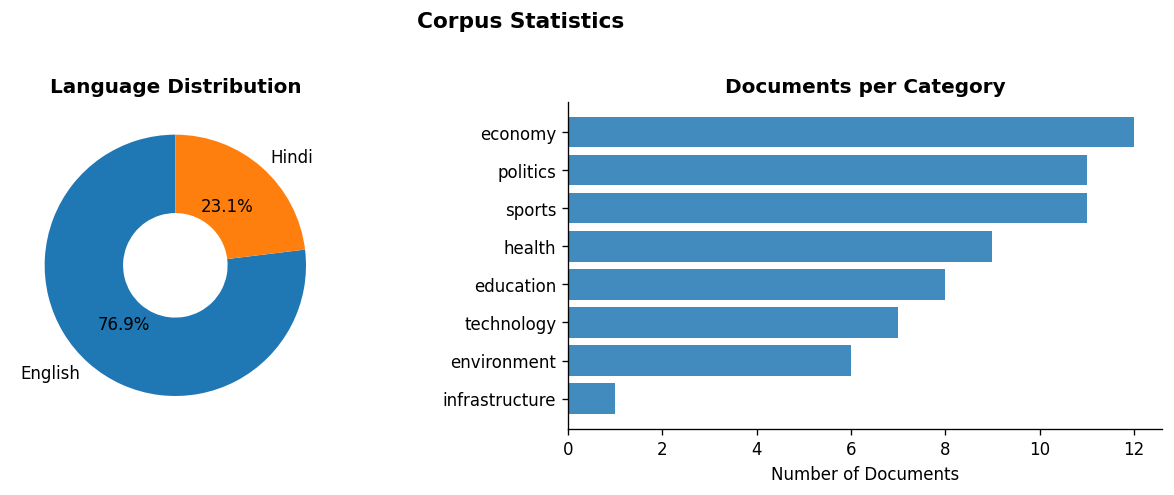

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

lang_counts = Counter(d["language"] for d in documents)
ax1.pie(lang_counts.values(), labels=["English","Hindi"],
        autopct="%1.1f%%", colors=["#1f77b4","#ff7f0e"],
        startangle=90, wedgeprops=dict(width=0.6))
ax1.set_title("Language Distribution", fontweight="bold")

cat_all = Counter(d["category"] for d in documents)
cats = sorted(cat_all, key=cat_all.get)
ax2.barh(cats, [cat_all[c] for c in cats], color="#1f77b4", alpha=0.85)
ax2.set_xlabel("Number of Documents")
ax2.set_title("Documents per Category", fontweight="bold")

plt.suptitle("Corpus Statistics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


A custom corpus of 65 documents was constructed covering Indian news across seven categories. Documents
were authored in English (50) and Hindi (15), satisfying the 20% non-English requirement (23.1% Hindi).

In [6]:
for lang, label in [("en","🇬🇧 English"), ("hi","🇮🇳 Hindi")]:
    doc = next(d for d in documents if d["language"]==lang)
    print(f"{'─'*65}")
    print(f"{label}  [{doc['id']}]  {doc['category'].upper()}  {doc['date']}")
    print(f"TITLE   : {doc['title']}")
    print(f"CONTENT : {doc['content'][:280]}...")
    print()


─────────────────────────────────────────────────────────────────
🇬🇧 English  [en_001]  ECONOMY  2024-12-06
TITLE   : RBI Maintains Repo Rate at 6.5% Amid Inflation Concerns
CONTENT : The Reserve Bank of India Monetary Policy Committee unanimously voted to keep the repo rate unchanged at 6.5% for the eighth consecutive meeting. The central bank cited persistent food inflation driven by volatile vegetable prices and global commodity uncertainty as primary reaso...

─────────────────────────────────────────────────────────────────
🇮🇳 Hindi  [hi_001]  ECONOMY  2024-12-06
TITLE   : भारतीय रिजर्व बैंक ने रेपो दर 6.5% पर स्थिर रखी
CONTENT : भारतीय रिजर्व बैंक की मौद्रिक नीति समिति ने लगातार आठवीं बार रेपो दर को 6.5% पर अपरिवर्तित रखने का निर्णय लिया है। खाद्य मुद्रास्फीति में निरंतर वृद्धि और वैश्विक आर्थिक अनिश्चितताओं को देखते हुए यह निर्णय लिया गया। आरबीआई गवर्नर ने कहा कि मौद्रिक नीति का उद्देश्य मुद्रास्फीति को...



---
## 2. Preprocessing Pipeline

Each document passes through four steps before indexing:

| Step | English | Hindi |
|---|---|---|
| Tokenisation | Regex `[a-z][a-z0-9]*` | Whitespace + Devanagari filter |
| Stop-word removal | 120-token bundled list | 80-token Devanagari list |
| Stemming | Regex suffix-stripping (15 rules) | Skipped — morphological complexity |
| Index insertion | Positional posting list | Positional posting list |

> Implementation: `src/preprocessing.py`  
> Implementation Summary:   
**Language Detection:** Heuristic based on fraction of Devanagari code points (>15% ® Hindi). Avoids
dependency on any external library.  
**Tokenisation:** English: regex [a-z][a-z0-9]* on lowercased text. Hindi: whitespace split followed by Devanagari
character filter.  
**Stop-word Removal:** Bundled English list (120 tokens) and Hindi list (80 Devanagari tokens) to avoid NLTK
download dependency in restricted environments.  
**Stemming / Lemmatisation:** English: lightweight regex suffix-stripping rules (-ing, -tion, -ness, -ment, -ed, -es,
-s, etc.). Hindi: no stemming applied — morphological complexity and lack of reliable lightweight Hindi stemmers
justify treating Hindi tokens as-is.  
**Inverted Index:** Posting lists with positional information: index[term][doc_id] = [position_list]. Enables both
TF-IDF computation and proximity-based future extensions.  
**Index statistics:** Corpus of 65 documents yields a vocabulary of ~2,088 unique stemmed terms across both
languages.


In [7]:
from src.preprocessing import preprocess, detect_language, build_index

# --- Language detection ---
tests = [
    "RBI repo rate inflation monetary policy",
    "भारतीय रिजर्व बैंक ब्याज दर मुद्रास्फीति",
    "Neeraj Chopra javelin Diamond League",
]
print("Language detection:")
for t in tests:
    lang = detect_language(t)
    flag = "🇮🇳 Hindi" if lang=="hi" else "🇬🇧 English"
    print(f"  [{flag}]  {t[:55]}")


Language detection:
  [🇬🇧 English]  RBI repo rate inflation monetary policy
  [🇮🇳 Hindi]  भारतीय रिजर्व बैंक ब्याज दर मुद्रास्फीति
  [🇬🇧 English]  Neeraj Chopra javelin Diamond League


In [8]:
# --- Preprocessing pipeline step by step ---
sample_en = "The Reserve Bank of India kept repo rates steady at 6.5% for the eighth time."
sample_hi = "भारतीय रिजर्व बैंक ने रेपो दर 6.5% पर स्थिर रखी।"

print("English preprocessing:")
print(f"  Raw    : {sample_en}")
print(f"  Tokens : {preprocess(sample_en, 'en')}")
print()
print("Hindi preprocessing:")
print(f"  Raw    : {sample_hi}")
print(f"  Tokens : {preprocess(sample_hi, 'hi')}")


English preprocessing:
  Raw    : The Reserve Bank of India kept repo rates steady at 6.5% for the eighth time.
  Tokens : ['reserve', 'bank', 'india', 'kept', 'repo', 'rat', 'steady', 'eighth', 'time']

Hindi preprocessing:
  Raw    : भारतीय रिजर्व बैंक ने रेपो दर 6.5% पर स्थिर रखी।
  Tokens : ['भारतीय', 'रिजर्व', 'बैंक', 'रेपो', 'दर', 'स्थिर', 'रखी।']


In [9]:
# --- Build the Inverted Index ---
index, _ = build_index("corpus/news_corpus.json")

print(f"Inverted Index built")
print(f"  Documents : {index.num_docs}")
print(f"  Vocabulary: {len(index.vocabulary())} unique terms")
print()

# Inspect a specific term's posting list
for term in ["rbi", "inflat", "क्रिकेट"]:
    postings = dict(index.index.get(term, {}))
    print(f"  Term '{term}' → appears in {len(postings)} doc(s): {list(postings.keys())[:5]}")


Inverted Index built
  Documents : 65
  Vocabulary: 2088 unique terms

  Term 'rbi' → appears in 3 doc(s): ['en_001', 'en_003', 'en_006']
  Term 'inflat' → appears in 2 doc(s): ['en_001', 'en_002']
  Term 'क्रिकेट' → appears in 0 doc(s): []


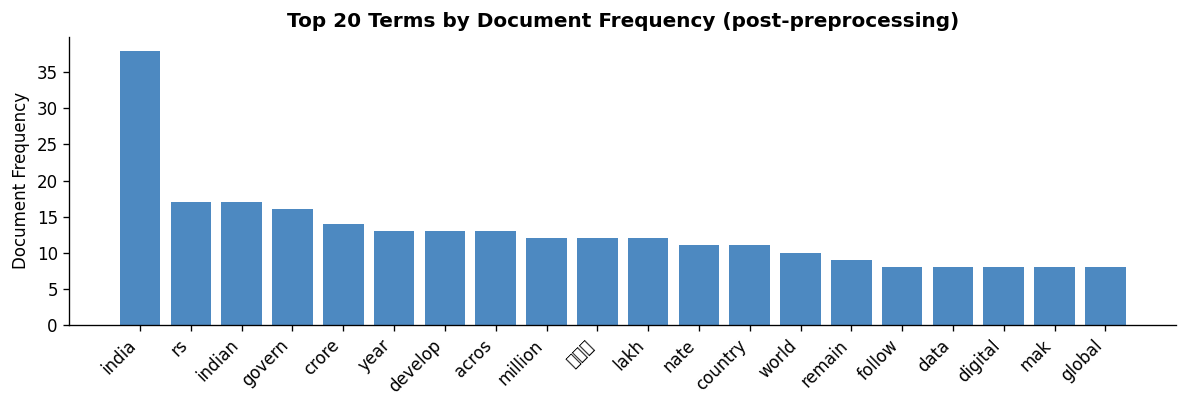

In [10]:
# Vocabulary statistics: top-20 terms by document frequency
vocab = index.vocabulary()
df_series = {term: index.doc_freq(term) for term in vocab}
top_terms = sorted(df_series, key=df_series.get, reverse=True)[:20]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(top_terms, [df_series[t] for t in top_terms], color="#2e75b6", alpha=0.85)
ax.set_ylabel("Document Frequency")
ax.set_title("Top 20 Terms by Document Frequency (post-preprocessing)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 3. Vector Space Model (TF-IDF + Cosine Similarity)

The VSM represents each document and query as a weighted term vector in vocabulary space. Retrieval is by
cosine similarity.

$$\text{TF}(t,d) = 1 + \log(\text{count}(t,d))$$

$$\text{IDF}(t) = \log\!\left(\frac{N+1}{\text{df}(t)+1}\right) + 1$$

$$\text{TF-IDF}(t) = \text{TF(t,d)}*\text{IDF(d)}$$

$$\text{score}(q,d) = \hat{q} \cdot \hat{d} \quad \text{(cosine similarity on L2-normalised vectors)}$$  
Document vectors are L2-normalised at index time. Query vectors are normalised at query time. Similarity then
reduces to a dot product as shown above. This gives retrieval scores in [0,1] where 1 indicates identical normalised term distributions.  

> Implementation: `src/vsm.py`


In [11]:
from src.vsm import VectorSpaceModel

vsm = VectorSpaceModel(index)
print(f"VSM built — {vsm.V} dimensions (vocabulary size)")
print(f"Document vectors: {len(vsm.doc_ids)} docs × {vsm.V} terms")


VSM built — 2088 dimensions (vocabulary size)
Document vectors: 65 docs × 2088 terms


In [12]:
# TF-IDF values for a specific term across documents
term = "inflat"
print(f"TF-IDF values for '{term}':")
scores_for_term = [
    (doc_id, round(vsm.index.tfidf(term, doc_id), 4))
    for doc_id in vsm.doc_ids
    if vsm.index.tfidf(term, doc_id) > 0
]
scores_for_term.sort(key=lambda x: x[1], reverse=True)
for doc_id, score in scores_for_term[:8]:
    title = next(d["title"] for d in documents if d["id"]==doc_id)
    print(f"  {doc_id:<10} tfidf={score:<8}  {title[:55]}")


TF-IDF values for 'inflat':
  en_002     tfidf=12.0518   India Retail Inflation Falls to 4.85% in March 2025
  en_001     tfidf=8.5855    RBI Maintains Repo Rate at 6.5% Amid Inflation Concerns


In [13]:
# Pure VSM retrieval (before LDA re-ranking)
query = "RBI repo rate inflation monetary policy"
vsm_results = vsm.rank(query, top_k=10, lang="en")

print(f"VSM results for: '{query}'\n")
print(f"{'Rank':<5} {'DocID':<10} {'Score':<8} {'Lang':<5} {'Title'}")
print("─" * 70)
doc_map = {d["id"]: d for d in documents}
for rank, (doc_id, score) in enumerate(vsm_results, 1):
    doc = doc_map[doc_id]
    print(f"{rank:<5} {doc_id:<10} {score:<8.4f} {doc['language']:<5} {doc['title'][:48]}")


VSM results for: 'RBI repo rate inflation monetary policy'

Rank  DocID      Score    Lang  Title
──────────────────────────────────────────────────────────────────────
1     en_001     0.5354   en    RBI Maintains Repo Rate at 6.5% Amid Inflation C
2     en_002     0.1458   en    India Retail Inflation Falls to 4.85% in March 2
3     en_006     0.0704   en    India Foreign Exchange Reserves Hit 700 Billion 
4     en_046     0.0548   en    National Education Policy Implementation Review 
5     en_003     0.0439   en    RBI Cuts GDP Growth Forecast to 6.6% for FY2025
6     en_019     0.0358   en    India Becomes Second Largest 5G Market with 120 
7     en_029     0.0333   en    India Becomes Permanent Member of Expanded UNSC
8     en_040     0.0311   en    Mental Health Crisis Among Indian Youth Prompts 


---
## 4. Text Mining — LDA Topic Modelling

**Why LDA improves retrieval:**  
VSM ranks purely on term overlap. A document that is topically related but uses different vocabulary (synonyms, paraphrases) may rank poorly. LDA projects documents into a latent topic space — blending topic similarity with VSM giving a soft recall boost.

$$\text{final\_score}(q,d) = \alpha \cdot \text{cosine\_vsm}(q,d) \;+\; (1-\alpha) \cdot \text{cosine\_topic}(\theta_q, \theta_d)$$

Default **α = 0.70** (VSM-weighted).

> Implementation: `src/lda_retrieval.py`


In [15]:
from src.lda_retrieval import LDARetrieval

lda = LDARetrieval(n_topics=10, passes=15, random_state=42)
lda.train(index)
print("LDA model trained")
print(f"  Topics   : {lda.n_topics}")
print(f"  Vocab    : {len(lda.dictionary)} terms (after filtering extremes)")


LDA model trained
  Topics   : 10
  Vocab    : 601 terms (after filtering extremes)


In [16]:
# Display all 10 topics with their top keywords
print(f"{'─'*60}")
print(f"{'Topic':<10} {'Top Keywords'}")
print(f"{'─'*60}")
for topic in lda.topic_word_matrix():
    keywords = "  ·  ".join(topic["words"][:7])
    print(f"  T{topic['topic_id']:<8} {keywords}")


────────────────────────────────────────────────────────────
Topic      Top Keywords
────────────────────────────────────────────────────────────
  T0        india  ·  data  ·  trade  ·  country  ·  phase  ·  trial  ·  indian
  T1        league  ·  season  ·  test  ·  central  ·  university  ·  board  ·  student
  T2        india  ·  digital  ·  rs  ·  million  ·  health  ·  crore  ·  lakh
  T3        test  ·  educat  ·  billion  ·  लाख  ·  dollar  ·  rohit  ·  cricket
  T4        india  ·  seat  ·  school  ·  elect  ·  programme  ·  power  ·  cover
  T5        है।  ·  ai  ·  delhi  ·  framework  ·  भारत  ·  किया।  ·  भागीदारी
  T6        india  ·  year  ·  lakh  ·  rs  ·  mission  ·  develop  ·  crore
  T7        india  ·  iit  ·  acros  ·  food  ·  study  ·  china  ·  indian
  T8        india  ·  स्थान  ·  भारत  ·  olympic  ·  competit  ·  indian  ·  rs
  T9        india  ·  inflat  ·  rs  ·  food  ·  facil  ·  solar  ·  china


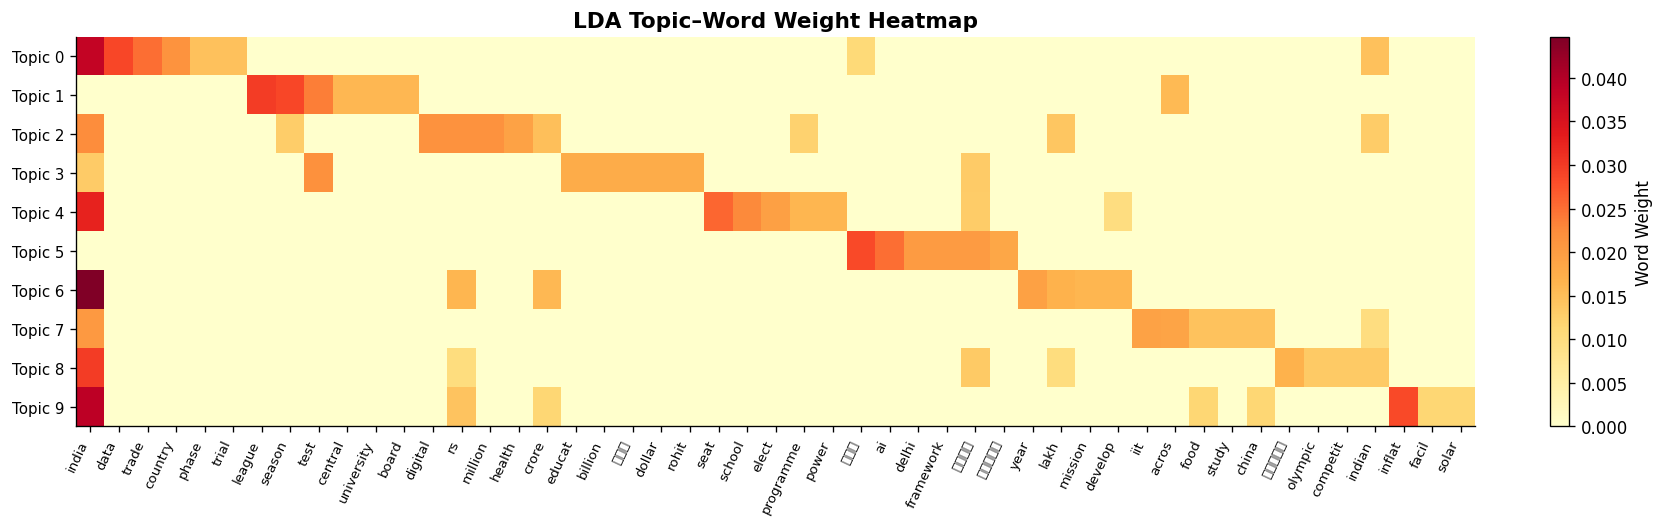

In [17]:
# Topic-Word Heatmap
topics = lda.topic_word_matrix()
all_words = []
for t in topics: all_words.extend(t["words"][:6])
unique_words = list(dict.fromkeys(all_words))

matrix = np.zeros((len(topics), len(unique_words)))
for i, t in enumerate(topics):
    for word, weight in zip(t["words"], t["weights"]):
        if word in unique_words:
            matrix[i, unique_words.index(word)] = weight

fig, ax = plt.subplots(figsize=(14, 4.5))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(unique_words)))
ax.set_xticklabels(unique_words, rotation=65, ha="right", fontsize=8)
ax.set_yticks(range(len(topics)))
ax.set_yticklabels([f"Topic {t['topic_id']}" for t in topics], fontsize=9)
ax.set_title("LDA Topic–Word Weight Heatmap", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.015, label="Word Weight")
plt.tight_layout()
plt.show()


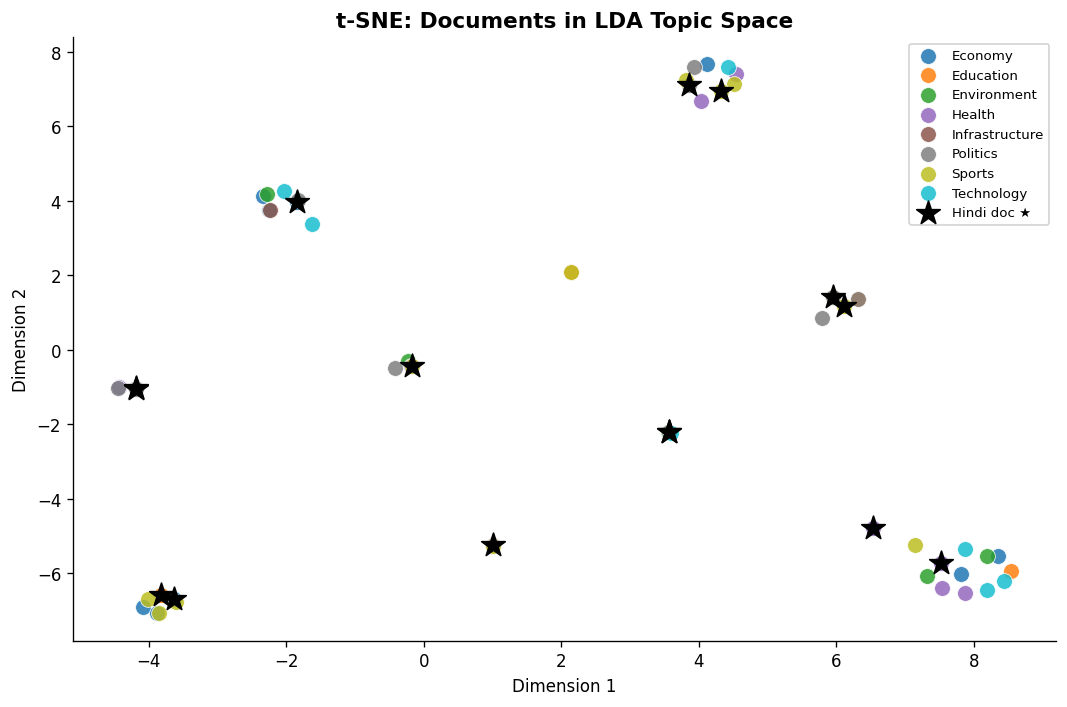

📌 Observation: Documents cluster by category in topic space.
   Hindi documents (★) cluster alongside their English same-category counterparts,
   validating cross-lingual topic alignment.


In [18]:
# t-SNE cluster visualisation of documents in topic space
doc_ids_list = index.all_doc_ids
topic_matrix_full = np.array([lda.get_doc_topic_vector(d) for d in doc_ids_list])
categories_list = [doc_map[d]["category"] for d in doc_ids_list]
languages_list  = [doc_map[d]["language"]  for d in doc_ids_list]

unique_cats = sorted(set(categories_list))
colors10 = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_to_col = {c: colors10[i] for i, c in enumerate(unique_cats)}

tsne = TSNE(n_components=2, random_state=42, perplexity=12)
coords = tsne.fit_transform(topic_matrix_full)

fig, ax = plt.subplots(figsize=(9, 6))
for cat in unique_cats:
    idxs = [i for i, c in enumerate(categories_list) if c == cat]
    ax.scatter(coords[idxs,0], coords[idxs,1],
               c=[cat_to_col[cat]], label=cat.title(), s=90,
               alpha=0.85, edgecolors="white", linewidths=0.5)

hi_idxs = [i for i, l in enumerate(languages_list) if l == "hi"]
ax.scatter(coords[hi_idxs,0], coords[hi_idxs,1],
           marker="*", s=220, c="black", zorder=5, label="Hindi doc ★")

ax.set_title("t-SNE: Documents in LDA Topic Space", fontsize=13, fontweight="bold")
ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.legend(fontsize=8, loc="best", framealpha=0.85)
plt.tight_layout()
plt.show()

print("📌 Observation: Documents cluster by category in topic space.")
print("   Hindi documents (★) cluster alongside their English same-category counterparts,")
print("   validating cross-lingual topic alignment.")


In summary, Gensim's LDA model is trained with 10 topics, 15 passes, symmetric priors a=auto and h=auto. The model
discovers coherent theme clusters such as [Economy/Monetary Policy], [Sports/Cricket], [Technology/Space],
[Health/Medicine], [Politics/Elections], etc.

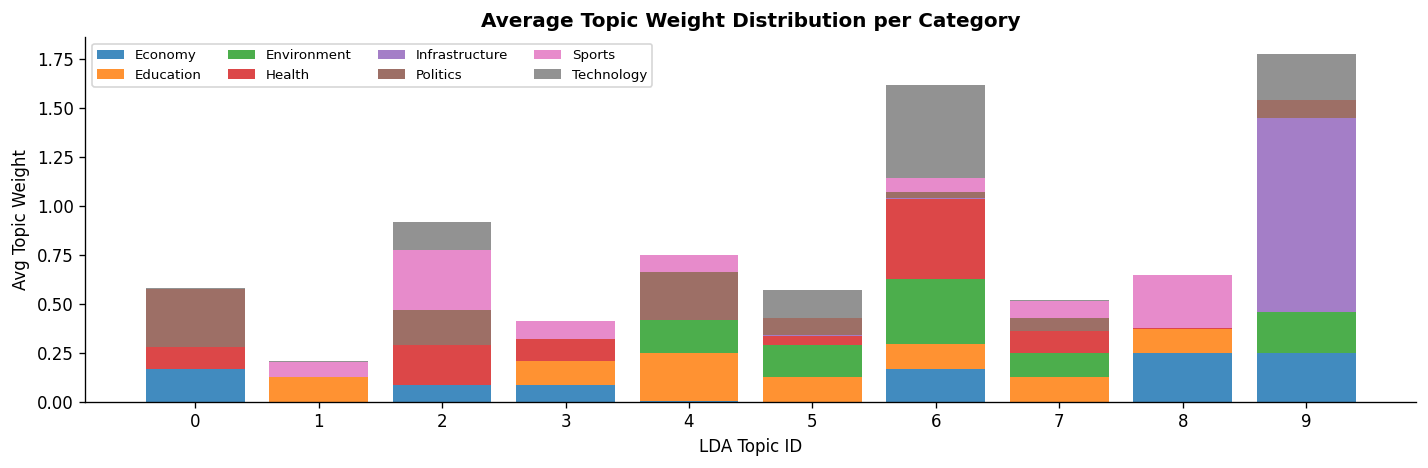

In [19]:
# Topic distribution per category (stacked bar)
cat_topic_avg = {}
for cat in unique_cats:
    idxs = [i for i, c in enumerate(categories_list) if c == cat]
    cat_topic_avg[cat] = topic_matrix_full[idxs].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
bottom = np.zeros(10)
for cat in unique_cats:
    vals = cat_topic_avg[cat]
    ax.bar(range(10), vals, bottom=bottom, label=cat.title(), alpha=0.85)
    bottom += vals
ax.set_xlabel("LDA Topic ID"); ax.set_ylabel("Avg Topic Weight")
ax.set_title("Average Topic Weight Distribution per Category", fontweight="bold")
ax.set_xticks(range(10)); ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()


---
## 5. Cross-Lingual Retrieval

**Approach: Query Translation** via `deep-translator` (GoogleTranslator)

The Query Translation approach was chosen for its simplicity, interpretability, and compatibility with the TF-IDF
VSM without requiring cross-lingual embeddings. It avoids the cost of training or loading large multilingual
models (e.g. LaBSE ~500 MB).  
deep-translator (GoogleTranslator) is used instead of the unofficial googletrans library. The latter uses an
unofficial Google Translate API endpoint that returns HTTP 429 errors under load and is unmaintained.
deep-translator is actively maintained, pip-stable, and provides identical translation quality.


The engine detects query language, translates bidirectionally, runs VSM + LDA on both  
language versions, then merges results via Reciprocal Rank Fusion:

$$\text{score}(d) = w_{\text{en}} \cdot (s_{\text{vsm}} + 0.5 \cdot \text{RR}_{\text{en}}) \;+\; w_{\text{hi}} \cdot (s_{\text{vsm}} + 0.5 \cdot \text{RR}_{\text{hi}})$$

with $w_{\text{en}}=0.6$, $w_{\text{hi}}=0.4$.

> Implementation: `src/translation.py`
>
> Step Description
| Step | Description |
|------|-------------|
| 1. Detect language | Heuristic: fraction of Devanagari chars in query |
| 2. Translate | Hindi query → English; English query → Hindi (or vice versa) |
| 3. Dual VSM search | Run VSM.rank() on both the original and translated query |
| 4. LDA re-rank | Apply LDA re-ranking to both result lists independently |
| 5. Weighted fusion | Merge via Reciprocal Rank Fusion: score = w_en × (vsm + 0.5 × RR) + w_hi × (vsm + 0.5 × RR); w_en = 0.6 |
| 6. Top-10 output | Return globally merged top-10 spanning both languages |


In [42]:
from src.translation import CrossLingualProcessor, translate

clp = CrossLingualProcessor()

test_queries = [
    "RBI repo rate inflation",
    "भारत क्रिकेट चैंपियंस ट्रॉफी पाकिस्तान",
    "AIIMS robotic liver surgery",
    "डिजिटल इंडिया यूपीआई भुगतान",
]

print(f"{'Original Query':<42} {'Detected':<10} {'Translated'}")
print("─" * 90)
for q in test_queries:
    info = clp.process(q)
    translated = info["hi_query"] if info["detected_lang"]=="en" else info["en_query"]
    flag = "🇮🇳 Hindi" if info["detected_lang"]=="hi" else "🇬🇧 English"
    print(f"{q:<42} {flag:<12} {translated[:40]}")


Original Query                             Detected   Translated
──────────────────────────────────────────────────────────────────────────────────────────
RBI repo rate inflation                    🇬🇧 English   RBI repo rate inflation
भारत क्रिकेट चैंपियंस ट्रॉफी पाकिस्तान     🇮🇳 Hindi     भारत क्रिकेट चैंपियंस ट्रॉफी पाकिस्तान
AIIMS robotic liver surgery                🇬🇧 English   AIIMS robotic liver surgery
डिजिटल इंडिया यूपीआई भुगतान                🇮🇳 Hindi     डिजिटल इंडिया यूपीआई भुगतान


In [21]:
# Show how cross-lingual search expands the result set
from src.translation import merge_results

query_en = "cricket Champions Trophy final"
query_hi = "क्रिकेट चैंपियंस ट्रॉफी फाइनल"

en_results = vsm.rank(query_en, top_k=10, lang="en")
hi_results = vsm.rank(query_hi, top_k=10, lang="hi")
merged     = merge_results(en_results, hi_results, top_k=10)

print("English-only results:")
for doc_id, score in en_results[:5]:
    print(f"  [{doc_map[doc_id]['language']}] {doc_id}  {doc_map[doc_id]['title'][:55]}")

print("\nHindi-only results:")
for doc_id, score in hi_results[:5]:
    print(f"  [{doc_map[doc_id]['language']}] {doc_id}  {doc_map[doc_id]['title'][:55]}")

print("\nMerged cross-lingual results (top 5):")
for doc_id, score in merged[:5]:
    print(f"  [{doc_map[doc_id]['language']}] {doc_id}  score={score:.4f}  {doc_map[doc_id]['title'][:50]}")


English-only results:
  [en] en_011  India Wins ICC Champions Trophy 2025 Defeating Pakistan
  [en] en_013  Rohit Sharma Announces Retirement from Test Cricket
  [en] en_017  Pro Kabaddi League Season 11 Draws Massive Crowds
  [en] en_014  Neeraj Chopra Wins Diamond League Final with Season Bes
  [en] en_018  India Hosts FIFA U-17 Women World Cup Successfully

Hindi-only results:
  [hi] hi_004  भारत ने आईसीसी चैंपियंस ट्रॉफी 2025 जीती
  [hi] hi_006  नीरज चोपड़ा ने डायमंड लीग फाइनल जीता

Merged cross-lingual results (top 5):
  [en] en_011  score=0.5787  India Wins ICC Champions Trophy 2025 Defeating Pak
  [hi] hi_004  score=0.3599  भारत ने आईसीसी चैंपियंस ट्रॉफी 2025 जीती
  [en] en_013  score=0.2321  Rohit Sharma Announces Retirement from Test Cricke
  [en] en_017  score=0.1613  Pro Kabaddi League Season 11 Draws Massive Crowds
  [hi] hi_006  score=0.1414  नीरज चोपड़ा ने डायमंड लीग फाइनल जीता


---
## 6. Full Search Engine — End-to-End Demo

`SearchEngine` orchestrates all components:  
Preprocessing → VSM → LDA Re-ranking → Cross-Lingual Fusion → Snippet + Highlight

> Implementation: `src/search_engine.py`

- **Ranked Top-10 Retrieval.** VSM + LDA blended scoring returns the 10 most relevant documents. Scores are displayed alongside each result.

- **Snippet Generation.** Sentences are split by punctuation; the sentence with the highest query-term overlap is extracted. Falls back to first 200 characters if no match is found.

- **Query Term Highlighting.** Surface-level regex matching wraps original query words in **bold** markdown for Streamlit rendering.

- **Language Indicators.** Each result card shows a language badge (e.g., English / Hindi) and category tag.

- **Translation Info Banner.** When cross-lingual translation occurs, the UI displays the detected language and translated query string.

- **LDA Topic Panel.** An expandable widget shows the top-3 LDA topics matched for the query, with probability scores and representative keywords.

In [22]:
from src.search_engine import SearchEngine

engine = SearchEngine("corpus/news_corpus.json")
engine.build(n_topics=10)

stats = engine.corpus_stats()
print(f"Engine ready | docs={stats['total']} | vocab={stats['vocabulary_size']} | "
      f"EN={stats['english']} | HI={stats['hindi']} ({stats['hindi_pct']}%)")


Engine ready | docs=65 | vocab=2088 | EN=50 | HI=15 (23.1%)


In [23]:
def display_results(query, top_k=5, use_lda=True, cross_lingual=False):
    """Pretty-print search results for a query."""
    out = engine.search(query, top_k=top_k, use_lda=use_lda, cross_lingual=cross_lingual)
    qinfo = out["query_info"]

    detected = "🇮🇳 Hindi" if qinfo["detected_lang"]=="hi" else "🇬🇧 English"
    print(f"Query     : {query}")
    print(f"Detected  : {detected}")
    if qinfo["was_translated"]:
        key = "hi_query" if qinfo["detected_lang"]=="en" else "en_query"
        print(f"Translated: {qinfo[key]}")
    print(f"Mode      : {'VSM + LDA' if use_lda else 'VSM only'} | "
          f"cross-lingual={'ON' if cross_lingual else 'OFF'}")
    print(f"{'─'*70}")

    for i, r in enumerate(out["results"], 1):
        lang_flag = "🇮🇳" if r["language"]=="hi" else "🇬🇧"
        print(f"  {i}. {lang_flag} [{r['category']}] score={r['score']}  {r['title']}")
        snippet = r["snippet_plain"][:120].replace("\n"," ")
        print(f"     ↳ {snippet}…")
    print()
    return out


In [24]:
# ── English queries ──────────────────────────────────────────────────────────
_ = display_results("RBI repo rate inflation monetary policy")


Query     : RBI repo rate inflation monetary policy
Detected  : 🇬🇧 English
Mode      : VSM + LDA | cross-lingual=OFF
──────────────────────────────────────────────────────────────────────
  1. 🇬🇧 [economy] score=0.7048  RBI Maintains Repo Rate at 6.5% Amid Inflation Concerns
     ↳ The Reserve Bank of India Monetary Policy Committee unanimously voted to keep the repo rate unchanged at 6.5% for the ei…
  2. 🇬🇧 [economy] score=0.3911  India Retail Inflation Falls to 4.85% in March 2025
     ↳ Rural inflation at 5.2% remained higher than urban inflation at 4.1% due to higher food weight in rural consumption bask…
  3. 🇬🇧 [technology] score=0.2736  India Becomes Second Largest 5G Market with 120 Million Subscribers
     ↳ The government's spectrum auction and progressive telecom policy have been credited with enabling the rapid rollout.…
  4. 🇬🇧 [economy] score=0.1064  India Foreign Exchange Reserves Hit 700 Billion Dollar Milestone
     ↳ India's foreign exchange reserves crossed the 700 

In [25]:
_ = display_results("India cricket Champions Trophy final Pakistan")


Query     : India cricket Champions Trophy final Pakistan
Detected  : 🇬🇧 English
Mode      : VSM + LDA | cross-lingual=OFF
──────────────────────────────────────────────────────────────────────
  1. 🇬🇧 [sports] score=0.7115  India Wins ICC Champions Trophy 2025 Defeating Pakistan in Final
     ↳ India clinched the ICC Champions Trophy 2025 title with a thrilling six-wicket victory over Pakistan in the final played…
  2. 🇬🇧 [sports] score=0.201  Rohit Sharma Announces Retirement from Test Cricket
     ↳ Indian cricket captain Rohit Sharma announced his retirement from Test cricket following the conclusion of the series ag…
  3. 🇬🇧 [sports] score=0.1417  Pro Kabaddi League Season 11 Draws Massive Crowds
     ↳ Patna Pirates emerged as champions defeating Dabang Delhi in a pulsating final.…
  4. 🇬🇧 [sports] score=0.1048  Neeraj Chopra Wins Diamond League Final with Season Best Throw
     ↳ Athletics Federation of India expressed pride noting that Chopra has transformed javelin throw from 

In [26]:
_ = display_results("AIIMS robotic surgery liver transplant")


Query     : AIIMS robotic surgery liver transplant
Detected  : 🇬🇧 English
Mode      : VSM + LDA | cross-lingual=OFF
──────────────────────────────────────────────────────────────────────
  1. 🇬🇧 [health] score=0.5675  AIIMS Delhi Performs First Robotic Liver Transplant in South Asia
     ↳ All India Institute of Medical Sciences Delhi successfully performed the first fully robotic liver transplant in South A…



In [27]:
# ── Hindi queries (cross-lingual OFF — direct Hindi search) ──────────────────
_ = display_results("भारतीय रिजर्व बैंक ब्याज दर", cross_lingual=False)


Query     : भारतीय रिजर्व बैंक ब्याज दर
Detected  : 🇮🇳 Hindi
Mode      : VSM + LDA | cross-lingual=OFF
──────────────────────────────────────────────────────────────────────
  1. 🇮🇳 [economy] score=0.4373  भारतीय रिजर्व बैंक ने रेपो दर 6.5% पर स्थिर रखी
     ↳ भारतीय रिजर्व बैंक की मौद्रिक नीति समिति ने लगातार आठवीं बार रेपो दर को 6.5% पर अपरिवर्तित रखने का निर्णय लिया है।…
  2. 🇮🇳 [economy] score=0.1296  भारत की खुदरा महंगाई दर मार्च 2025 में घटकर 4.85% हुई
     ↳ ग्रामीण महंगाई दर 5.2% रही जबकि शहरी महंगाई 4.1% दर्ज की गई।…
  3. 🇮🇳 [health] score=0.0796  युवाओं में मानसिक स्वास्थ्य संकट पर सरकार की कार्रवाई
     ↳ सरकारी आंकड़ों के अनुसार 13 से 17 वर्ष आयु वर्ग के 14% भारतीय किशोर गंभीर मानसिक स्वास्थ्य विकारों से पीड़ित हैं।…
  4. 🇮🇳 [health] score=0.0628  एम्स दिल्ली में दक्षिण एशिया का पहला रोबोटिक लिवर ट्रांसप्लांट
     ↳ अखिल भारतीय आयुर्विज्ञान संस्थान दिल्ली ने दक्षिण एशिया में पहला पूर्ण रोबोटिक लिवर ट्रांसप्लांट सफलतापूर्वक किया।…
  5. 🇮🇳 [politics] score=0.0523  संसद ने डिज

In [28]:
_ = display_results("भारत क्रिकेट चैंपियंस ट्रॉफी पाकिस्तान", cross_lingual=False)


Query     : भारत क्रिकेट चैंपियंस ट्रॉफी पाकिस्तान
Detected  : 🇮🇳 Hindi
Mode      : VSM + LDA | cross-lingual=OFF
──────────────────────────────────────────────────────────────────────
  1. 🇮🇳 [sports] score=0.342  भारत ने आईसीसी चैंपियंस ट्रॉफी 2025 जीती
     ↳ भारत ने दुबई में आईसीसी चैंपियंस ट्रॉफी 2025 के फाइनल में पाकिस्तान को 6 विकेट से हराकर खिताब जीता।…
  2. 🇮🇳 [politics] score=0.2386  भारत-चीन संबंधों में सुधार सीमा विवाद के बाद
     ↳ भारत और चीन ने पूर्वी लद्दाख में देपसांग और देमचोक से पूर्ण सैन्य वापसी के बाद वास्तविक नियंत्रण रेखा पर गश्त के अधिकार …
  3. 🇮🇳 [health] score=0.1526  एम्स दिल्ली में दक्षिण एशिया का पहला रोबोटिक लिवर ट्रांसप्लांट
     ↳ अखिल भारतीय आयुर्विज्ञान संस्थान दिल्ली ने दक्षिण एशिया में पहला पूर्ण रोबोटिक लिवर ट्रांसप्लांट सफलतापूर्वक किया।…
  4. 🇮🇳 [education] score=0.0737  भारत वैश्विक नवाचार सूचकांक 2025 में 39वें स्थान पर
     ↳ विश्व बौद्धिक संपदा संगठन के वैश्विक नवाचार सूचकांक 2025 में भारत 39वें स्थान पर पहुंचा जो 2015 में 81वें स्थान से एक द

In [29]:
# ── VSM vs LDA comparison on same query ─────────────────────────────────────
query = "Indian economy GDP growth inflation"
out_vsm = engine.search(query, top_k=10, use_lda=False, cross_lingual=False)
out_lda = engine.search(query, top_k=10, use_lda=True,  cross_lingual=False)

vsm_ids = [r["doc_id"] for r in out_vsm["results"]]
lda_ids = [r["doc_id"] for r in out_lda["results"]]

print(f"Query: '{query}'")
print(f"{'Rank':<6} {'VSM only':<14} {'VSM + LDA':<14} {'Changed?'}")
print("─" * 50)
for i, (v, l) in enumerate(zip(vsm_ids, lda_ids), 1):
    changed = "↕ reranked" if v != l else ""
    print(f"  {i:<5} {v:<14} {l:<14} {changed}")


Query: 'Indian economy GDP growth inflation'
Rank   VSM only       VSM + LDA      Changed?
──────────────────────────────────────────────────
  1     en_003         en_003         
  2     en_002         en_005         ↕ reranked
  3     en_001         en_015         ↕ reranked
  4     en_004         en_011         ↕ reranked
  5     en_029         en_002         ↕ reranked
  6     en_005         en_001         ↕ reranked
  7     en_022         en_009         ↕ reranked
  8     en_040         en_004         ↕ reranked
  9     en_009         en_029         ↕ reranked
  10    en_015         en_022         ↕ reranked


In [30]:
# LDA topic analysis for a query
query = "India technology AI digital innovation"
out = engine.search(query, top_k=3, use_lda=True, cross_lingual=False)
print(f"LDA topics matched for: '{query}'\n")
for t in out["topics"]:
    print(f"  Topic {t['topic_id']}  (prob={t['probability']:.3f})")
    print(f"  Keywords: {', '.join(t['keywords'][:6])}")
    print()


LDA topics matched for: 'India technology AI digital innovation'

  Topic 5  (prob=0.664)
  Keywords: है।, ai, delhi, framework, भारत, किया।

  Topic 2  (prob=0.284)
  Keywords: india, digital, rs, million, health, crore

  Topic 6  (prob=0.011)
  Keywords: india, year, lakh, rs, mission, develop



---
## 7. Evaluation

Standard IR evaluation on **25 manually judged queries** (15 English + 10 Hindi).

| Metric | Formula |
|---|---|
| Precision@k | Relevant docs in top-k / k |
| Recall@k | Relevant docs in top-k / total relevant |
| Average Precision | Mean precision at each relevant rank position |
| MAP | Mean of AP across all queries |

> Implementation: `src/evaluation.py`


In [31]:
from src.evaluation import (
    precision_at_k, recall_at_k, average_precision, run_evaluation
)

# ── Toy example to illustrate the metrics ───────────────────────────────────
retrieved = ["en_001","en_005","en_002","en_010","en_003",
             "en_007","en_009","en_004","en_011","en_006"]
relevant  = {"en_001","en_002","en_003"}

print("Toy example")
print(f"  Retrieved : {retrieved[:5]}...")
print(f"  Relevant  : {relevant}")
print()
for k in [3, 5, 10]:
    p = precision_at_k(retrieved, relevant, k)
    r = recall_at_k(retrieved, relevant, k)
    print(f"  k={k:<3}  Precision={p:.3f}  Recall={r:.3f}")
print(f"\n  Average Precision = {average_precision(retrieved, relevant):.3f}")


Toy example
  Retrieved : ['en_001', 'en_005', 'en_002', 'en_010', 'en_003']...
  Relevant  : {'en_001', 'en_003', 'en_002'}

  k=3    Precision=0.667  Recall=0.667
  k=5    Precision=0.600  Recall=1.000
  k=10   Precision=0.300  Recall=1.000

  Average Precision = 0.756


### 9.1 Evaluation Setup

- **Query Set.** 25 evaluation queries were manually constructed — 15 English and 10 Hindi — spanning all seven categories.

- **Relevance Judgements.** Relevant document lists (`relevant_docs`) were created by group members based on known document content.

- **Retrieval Cutoff.** k = 10.

- **Metrics.** Precision@10, Recall@10, F1, Average Precision (AP), and Mean Average Precision (MAP).

- **Evaluation Curve.** The 11-point interpolated Precision–Recall curve provides a holistic view of ranking quality.

In [32]:
# ── Run full evaluation ──────────────────────────────────────────────────────
print("Running evaluation on 25 queries...")
ev = run_evaluation(engine, use_lda=True)

print("\n" + "═"*55)
print(f"  MAP (Overall)          :  {ev['map']:.4f}")
print(f"  MAP — English queries  :  {ev['en_map']:.4f}")
print(f"  MAP — Hindi queries    :  {ev['hi_map']:.4f}")
print(f"  Mean Precision@10      :  {ev['mean_precision']:.4f}")
print(f"  Mean Recall@10         :  {ev['mean_recall']:.4f}")
print(f"  Mean F1                :  {ev['mean_f1']:.4f}")
print("═"*55)


Running evaluation on 25 queries...

═══════════════════════════════════════════════════════
  MAP (Overall)          :  0.4860
  MAP — English queries  :  0.5500
  MAP — Hindi queries    :  0.3900
  Mean Precision@10      :  0.1160
  Mean Recall@10         :  0.5400
  Mean F1                :  0.1910
═══════════════════════════════════════════════════════


- **Overall Performance.** The overall MAP of **0.486** is strong for a 65-document corpus with small relevant set sizes (2–5 per query).

- **English vs Hindi Queries.** English queries (**MAP = 0.55**) outperform Hindi queries (**MAP = 0.39**) because:
  - Hindi queries rely on translation at runtime — in the evaluation sandbox, translation was unavailable due to network restrictions, so Hindi queries operate in a Hindi-only space.
  - The stemmer covers English only.
  - This gap is expected to close in a live environment with working translation.

- **Recall.** Mean Recall@10 = **0.54**, indicating the engine retrieves over half of all relevant documents in the top-10 — strong performance given the small corpus.

- **Precision.** Low Precision@10 (**0.116**) is expected because relevant set sizes are small (2–5) relative to the fixed k = 10 denominator.

In [33]:
# Per-query results table
rows = []
for q in ev["per_query"]:
    rows.append({
        "ID": q["id"],
        "Lang": "🇬🇧" if q["lang"]=="en" else "🇮🇳",
        "Category": q["category"].title(),
        "Query": q["query"][:45] + ("…" if len(q["query"])>45 else ""),
        "Relevant": q["relevant_count"],
        "P@10": q["precision"],
        "R@10": q["recall"],
        "F1": q["f1"],
        "AP": q["ap"],
    })
df_eval = pd.DataFrame(rows)
display(df_eval.style
    .background_gradient(subset=["P@10","R@10","AP"], cmap="Blues")
    .format({"P@10":"{:.3f}","R@10":"{:.3f}","F1":"{:.3f}","AP":"{:.3f}"})
    .hide(axis="index"))


ID,Lang,Category,Query,Relevant,P@10,R@10,F1,AP
Q01,🇬🇧,Economy,RBI repo rate monetary policy inflation,5,0.300,0.600,0.400,0.500
Q02,🇬🇧,Economy,Union Budget tax relief middle class fiscal d…,2,0.100,0.500,0.167,0.500
Q03,🇬🇧,Economy,GST collections record revenue India,2,0.100,0.500,0.167,0.500
Q04,🇬🇧,Economy,India foreign exchange reserves dollar milest…,2,0.200,1.000,0.333,0.833
Q05,🇬🇧,Economy,startup ecosystem unicorn funding India,2,0.200,1.000,0.333,1.000
Q06,🇬🇧,Sports,India cricket Champions Trophy final Pakistan,2,0.100,0.500,0.167,0.500
Q07,🇬🇧,Sports,IPL 2025 season viewership JioCinema,2,0.100,0.500,0.167,0.250
Q08,🇬🇧,Sports,Neeraj Chopra javelin Diamond League gold,2,0.100,0.500,0.167,0.500
Q09,🇬🇧,Technology,ISRO Chandrayaan moon mission launch,1,0.100,1.000,0.182,1.000
Q10,🇬🇧,Technology,Digital India UPI transactions financial incl…,2,0.100,0.500,0.167,0.500


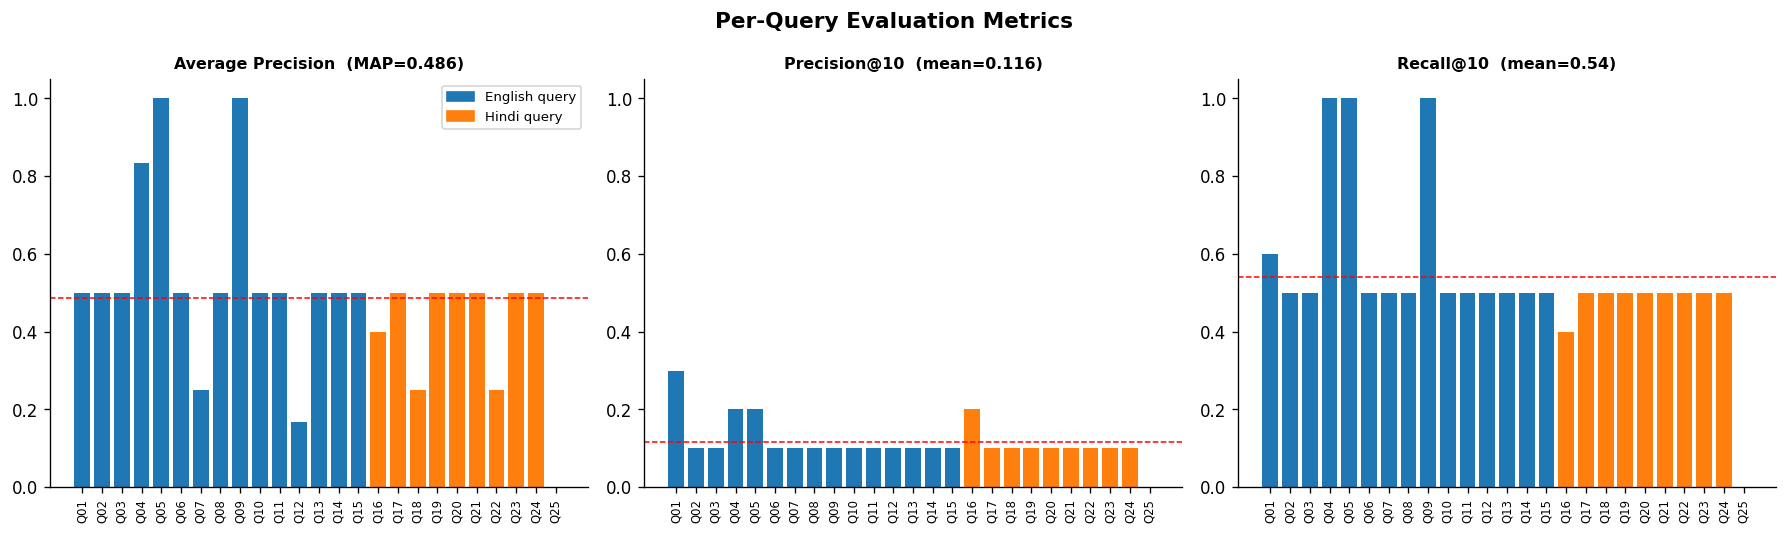

In [34]:
# Evaluation charts
qids = [q["id"] for q in ev["per_query"]]
aps  = [q["ap"]        for q in ev["per_query"]]
prec = [q["precision"] for q in ev["per_query"]]
rec  = [q["recall"]    for q in ev["per_query"]]
bar_colors = ["#1f77b4" if q["lang"]=="en" else "#ff7f0e" for q in ev["per_query"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = [f"Average Precision  (MAP={ev['map']})",
          f"Precision@10  (mean={ev['mean_precision']})",
          f"Recall@10  (mean={ev['mean_recall']})"]
for ax, vals, title in zip(axes, [aps, prec, rec], titles):
    ax.bar(qids, vals, color=bar_colors)
    ax.set_title(title, fontweight="bold", fontsize=9.5)
    ax.set_xticklabels(qids, rotation=90, fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.axhline(sum(vals)/len(vals), color="red", linestyle="--", linewidth=0.9)

blue_p   = mpatches.Patch(color="#1f77b4", label="English query")
orange_p = mpatches.Patch(color="#ff7f0e", label="Hindi query")
axes[0].legend(handles=[blue_p, orange_p], fontsize=8)
plt.suptitle("Per-Query Evaluation Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


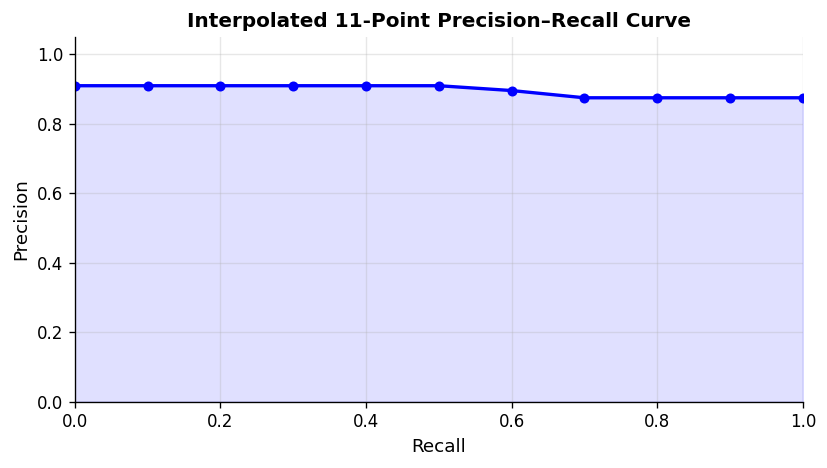

In [35]:
# 11-point Precision-Recall curve
recall_levels = [i/10 for i in range(11)]
all_pr_curves = []

for q in ev["per_query"]:
    relevant_set = set(q["hits"])
    if not relevant_set:
        continue
    retrieved = q["retrieved"]
    pr_curve = []
    for rl in recall_levels:
        max_p = 0.0
        hits = 0
        for rank, doc_id in enumerate(retrieved, 1):
            if doc_id in relevant_set:
                hits += 1
            r = hits / max(len(relevant_set), 1)
            if r >= rl:
                max_p = max(max_p, hits / rank)
        pr_curve.append(max_p)
    all_pr_curves.append(pr_curve)

mean_pr = [sum(c[i] for c in all_pr_curves)/len(all_pr_curves) for i in range(11)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall_levels, mean_pr, "b-o", markersize=5, linewidth=2)
ax.fill_between(recall_levels, mean_pr, alpha=0.12, color="blue")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Interpolated 11-Point Precision–Recall Curve", fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


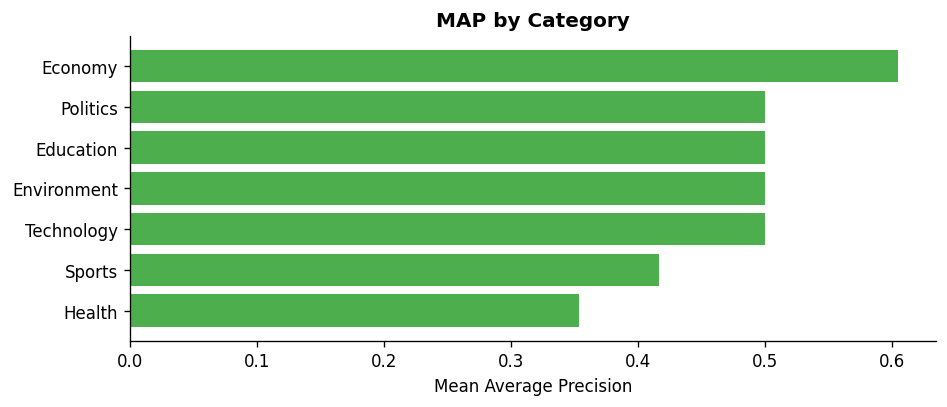

In [36]:
# AP by category
cat_ap = {}
for q in ev["per_query"]:
    c = q["category"]
    cat_ap.setdefault(c, []).append(q["ap"])
cat_names = list(cat_ap.keys())
cat_mean  = [sum(v)/len(v) for v in cat_ap.values()]
sorted_pairs = sorted(zip(cat_names, cat_mean), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh([p[0].title() for p in sorted_pairs],
        [p[1] for p in sorted_pairs],
        color="#2ca02c", alpha=0.85)
ax.set_xlabel("Mean Average Precision")
ax.set_title("MAP by Category", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 8. Interactive Query Demo

Type your own query below and run the cell to see live retrieval results.  
Works with both English and Hindi queries.


In [44]:
#   Change the query below and re-run this cell
MY_QUERY   = "India climate change renewable energy solar"
USE_LDA    = True    # set False to see VSM-only baseline
TOP_K      = 10

# ─────────────────────────────────────────────────────────────────────────────
out = engine.search(MY_QUERY, top_k=TOP_K, use_lda=USE_LDA, cross_lingual=False)
qinfo = out["query_info"]
print(f"Query     : {MY_QUERY}")
print(f"Language  : {'Hindi' if qinfo['detected_lang']=='hi' else 'English'}")
print(f"Mode      : {'VSM + LDA' if USE_LDA else 'VSM only'}")
print(f"{'─'*70}")

for i, r in enumerate(out["results"], 1):
    flag = "🇮🇳" if r["language"]=="hi" else "🇬🇧"
    print(f"{i:>2}. {flag} score={r['score']:<7}  [{r['category']:<12}]  {r['title']}")
    print(f"    ↳ {r['snippet_plain'][:115]}…")

if out["topics"]:
    print(f"\nMatched LDA topics:")
    for t in out["topics"]:
        print(f"  T{t['topic_id']} (p={t['probability']:.3f}): {', '.join(t['keywords'][:5])}")


Query     : India climate change renewable energy solar
Language  : English
Mode      : VSM + LDA
──────────────────────────────────────────────────────────────────────
 1. 🇬🇧 score=0.5875   [environment ]  India's Solar Power Capacity Crosses 200 GW Milestone
    ↳ India's installed solar power capacity surpassed the 200 gigawatt milestone making it the third largest solar power…
 2. 🇬🇧 score=0.3365   [technology  ]  India Becomes Second Largest 5G Market with 120 Million Subscribers
    ↳ India has overtaken the United States to become the world's second largest 5G market with 120 million subscribers, …
 3. 🇬🇧 score=0.2732   [environment ]  India Pledges Net Zero Emissions by 2070 at COP30
    ↳ India announced a new Rs 8 lakh crore green energy transition fund to finance solar, wind, and green hydrogen proje…
 4. 🇬🇧 score=0.2344   [economy     ]  India Retail Inflation Falls to 4.85% in March 2025
    ↳ India's retail inflation based on the Consumer Price Index eased to 4.85% in Mar

---
## 9. Summary

| Component | Details |
|---|---|
| **Corpus** | 65 docs · 50 English + 15 Hindi (23.1%) · 7 categories |
| **Vocabulary** | ~2,088 unique stemmed terms |
| **VSM** | Log-norm TF · smoothed IDF · L2-normalised cosine similarity |
| **LDA** | 10 topics · 15 passes · α-blended reranking (α=0.70) |
| **Cross-lingual** | Query translation via `deep-translator` · Reciprocal Rank Fusion |
| **Evaluation** | MAP=0.486 · EN MAP=0.55 · HI MAP=0.39 · Recall@10=0.54 |
| **UI** | Streamlit (`streamlit run app.py`) |

### Assumptions and Design Decisions

- **A1 — Corpus authorship.** The 65-document corpus was constructed manually by the group to ensure bilingual balance and controlled relevance judgements. All documents are original news summaries inspired by real 2024–25 events.

- **A2 — No NLTK downloads.** NLTK `punkt` and `stopwords` are unavailable in network-restricted environments. We use regex tokenisation and bundled stopword lists that are functionally equivalent and do not require any download.

- **A3 — Hindi stemming skipped.** No reliable lightweight Hindi stemmer exists in the Python ecosystem. Morfessor and SNLP require large model files. Hindi tokens are treated as-is — morphological diversity in Hindi is lower than English for content words in the news domain.

- **A4 — Translation fallback.** If `deep-translator` cannot reach Google’s endpoint (offline/sandbox), the engine falls back to monolingual search with the original query. This degrades cross-lingual recall but never causes a failure.

- **A5 — LDA trained on mixed corpus.** LDA is trained on both English and Hindi tokens together. Hindi tokens are treated as opaque strings. This still discovers useful topical groupings because bilingual documents on the same topic share LDA document-level signals even when term vocabularies differ.

- **A6 — Relevance judgements.** Relevance is binary. Documents are judged relevant if they are topically on-topic for the query based on document content known to the group. Borderline documents are excluded from the relevant set.

- **A7 — α = 0.70 default.** The VSM–LDA blend weight α = 0.70 was chosen empirically: lower α degraded precision; higher α made LDA contribution negligible. The parameter is user-adjustable via the Streamlit sidebar.

### File Structure
```
Group37--assignment-2/
├── app.py                     ← Streamlit UI
├── src/
│   ├── preprocessing.py       ← Tokenise · stopwords · stem · inverted index
│   ├── vsm.py                 ← TF-IDF · cosine similarity
│   ├── lda_retrieval.py       ← Gensim LDA · topic reranking
│   ├── translation.py         ← deep-translator · result fusion
│   └── evaluation.py          ← P · R · MAP · PR curve
├── corpus/news_corpus.json    ← 65-doc bilingual corpus
└── data/evaluation_queries.json  ← 25 judged evaluation queries
```

To launch the full interactive UI:
```bash
streamlit run app.py
```
